# Pizza Place Sales Analysis

- The analysis uses four datasets:
- orders.csv
- order_details.csv
- pizzas.csv
- pizza_types.csv

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

%matplotlib in line

In [4]:
#Load the Datasets

orders = pd.read_csv(r"C:\Users\hp\Documents\Cohort 7 Notebook\pizza_sales\orders.csv")
order_details = pd.read_csv(r"C:\Users\hp\Documents\Cohort 7 Notebook\pizza_sales\order_details.csv")
pizzas = pd.read_csv(r"C:\Users\hp\Documents\Cohort 7 Notebook\pizza_sales\pizzas.csv")
pizza_types = pd.read_csv(r"C:\Users\hp\Documents\Cohort 7 Notebook\pizza_sales\pizza_types.csv", encoding="latin1")

In [8]:
#Preview each dataset

display(orders.head())
display(order_details.head())
display(pizzas.head())
display(pizza_types.head())

,order_id,date,time
0,1,2015-01-01,11:38:36
1,2,2015-01-01,11:57:40
2,3,2015-01-01,12:12:28
3,4,2015-01-01,12:16:31
4,5,2015-01-01,12:21:30


,order_details_id,order_id,pizza_id,quantity
0,1,1,hawaiian_m,1
1,2,2,classic_dlx_m,1
2,3,2,five_cheese_l,1
3,4,2,ital_supr_l,1
4,5,2,mexicana_m,1


,pizza_id,pizza_type_id,size,price
0,bbq_ckn_s,bbq_ckn,S,12.75
1,bbq_ckn_m,bbq_ckn,M,16.75
2,bbq_ckn_l,bbq_ckn,L,20.75
3,cali_ckn_s,cali_ckn,S,12.75
4,cali_ckn_m,cali_ckn,M,16.75


,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."
2,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
3,ckn_pesto,The Chicken Pesto Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Spinach, Garli..."
4,southw_ckn,The Southwest Chicken Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Red Onions, Ja..."


In [10]:
#Check dataset shapes

print("Orders shape:", orders.shape)
print("Order details shape:", order_details.shape)
print("Pizzas shape:", pizzas.shape)
print("Pizza types shape:", pizza_types.shape)

Orders shape: (21350, 3)
Order details shape: (48620, 4)
Pizzas shape: (96, 4)
Pizza types shape: (32, 4)


In [12]:
#Check missing values

print("Missing values in orders:")
print(orders.isnull().sum())

print("\nMissing values in order_details:")
print(order_details.isnull().sum())

print("\nMissing values in pizzas:")
print(pizzas.isnull().sum())

print("\nMissing values in pizza_types:")
print(pizza_types.isnull().sum())

Missing values in orders:
order_id    0
date        0
time        0
dtype: int64

Missing values in order_details:
order_details_id    0
order_id            0
pizza_id            0
quantity            0
dtype: int64

Missing values in pizzas:
pizza_id         0
pizza_type_id    0
size             0
price            0
dtype: int64

Missing values in pizza_types:
pizza_type_id    0
name             0
category         0
ingredients      0
dtype: int64


# Merge the Datasets
- The four tables are joined into one main DataFrame so all orders, pizza, price, size, category, and ingredient information can be analyzed together

In [16]:
#Merge all datasets into one DataFrame

df = order_details.merge(orders, on="order_id") \
                  .merge(pizzas, on="pizza_id") \
                  .merge(pizza_types, on="pizza_type_id")

df.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go..."
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni..."
4,5,2,mexicana_m,1,2015-01-01,11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."


In [24]:
#Create useful time and revenue columns

df["date"] = pd.to_datetime(df["date"])
df["time"] = pd.to_datetime(df["time"], format="%H:%M:%S").dt.time
df["datetime"] = pd.to_datetime(df["date"].astype(str) + " " + df["time"].astype(str))

df["hour"] = df["datetime"].dt.hour
df["day_name"] = df["datetime"].dt.day_name()
df["month"] = df["datetime"].dt.month
df["month_name"] = df["datetime"].dt.month_name() 

df["revenue"] = df["quantity"] * df["price"]

df.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients,datetime,hour,day_name,month,month_name,revenue
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",2015-01-01 11:38:36,11,Thursday,1,January,13.25
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",2015-01-01 11:57:40,11,Thursday,1,January,16.00
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",2015-01-01 11:57:40,11,Thursday,1,January,18.50
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",2015-01-01 11:57:40,11,Thursday,1,January,20.75
4,5,2,mexicana_m,1,2015-01-01,11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",2015-01-01 11:57:40,11,Thursday,1,January,16.00


In [26]:
#Basic information about the final merge dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_details_id  48620 non-null  int64         
 1   order_id          48620 non-null  int64         
 2   pizza_id          48620 non-null  object        
 3   quantity          48620 non-null  int64         
 4   date              48620 non-null  datetime64[ns]
 5   time              48620 non-null  object        
 6   pizza_type_id     48620 non-null  object        
 7   size              48620 non-null  object        
 8   price             48620 non-null  float64       
 9   name              48620 non-null  object        
 10  category          48620 non-null  object        
 11  ingredients       48620 non-null  object        
 12  datetime          48620 non-null  datetime64[ns]
 13  hour              48620 non-null  int32         
 14  day_name          4862

# Total Revenue/Sales
- Insight: The pizza geneerated$817.05 in total revenue for the year. This shows string annual sales performance across all pizza categories and sizes

In [29]:
total_revenue = df["revenue"].sum()
print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $817,860.05


# Total Quantity Sold
- Insight: The restaurant sold $49,574 pizzas in total during the year. This shows that the business had a high order volume

In [33]:
total_quantity = df["quantity"].sum()
print(f"Quantity Sold: ${total_quantity:,}")

Quantity Sold: $49,574


# Total Orders
- Insights: 21,350 total orders during the year. Sine total pizzas sold are higher than total orders,many customers higher more than one  pizza per order

In [39]:
total_orders = df["order_id"].nunique()
print(f"Total Orders: {total_orders:,}")

Total Orders: 21,350


# Number of Pizza Types
- Insight: The restaurant sells 32 different pizza types, giving customers a wide variety of menu options

# Average Price of Pizzas

- Insight: The average order value is $16.44. This gives a general idea of the restaurant's pricing level across all sizes and pizza types

In [47]:
average_price = pizzas["price"].mean()
print(f"Average Pizza Price: ${average_price:.2f}")

Average Pizza Price: $16.44


# Avearge Order Value
- Insight: The average order value is $38.31, which means customers usually buy multiple pizzas or higher -priced pizzas per order

In [53]:
average_order_value = df.groupby("order_id")["revenue"].sum().mean()
print(f"Average Order Value: ${average_order_value:.2f}")

Average Order Value: $38.31


# Peak Hours of Sales
- Insight: The peak hours is 12:00PM, with $111,877.90 in revenue and 6,776 pizza sold.Lunch hours are especially strong, followed by evening dinner hours

In [62]:
hourly_sales = df.groupby("hour").agg(
    total_quantity=("quantity", "sum"),
    total_revenue=("quantity", "sum"),
    total_orders=("order_id", "nunique")
).reset_index()

hourly_sales

,hour,total_quantity,total_revenue,total_orders
0,9,4,4,1
1,10,18,18,8
2,11,2728,2728,1231
3,12,6776,6776,2520
4,13,6413,6413,2455
5,14,3613,3613,1472
6,15,3216,3216,1468
7,16,4239,4239,1920
8,17,5211,5211,2336
9,18,5417,5417,2399


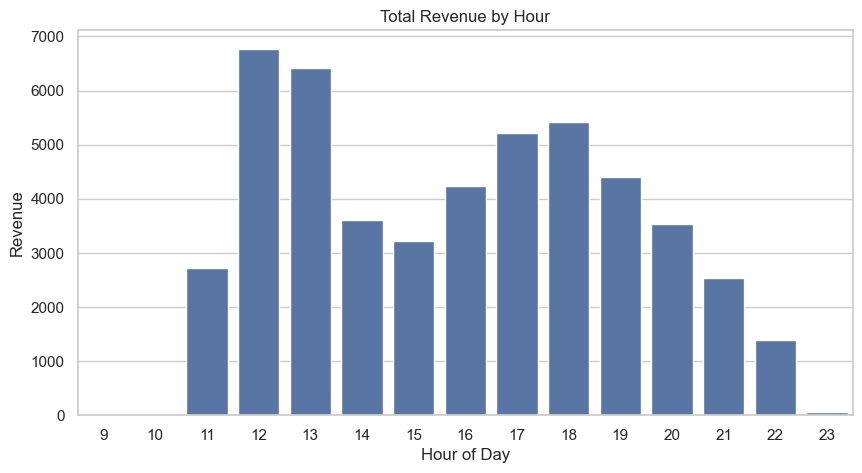

In [68]:
plt.figure(figsize=(10, 5))
sns.barplot(data=hourly_sales, x="hour", y="total_revenue")
plt.title("Total Revenue by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.show()

In [72]:
peak_hour = hourly_sales.sort_values("total_revenue", ascending=False).iloc[0]
print(f"Peak Sales hour: {int(peak_hour['hour'])}:00")
print(f"Revenue during peak hour: ${peak_hour['total_revenue']:,.2f}")
print(f"Quantity sold during peak hour: {int(peak_hour['total_quantity']):,}")

Peak Sales hour: 12:00
Revenue during peak hour: $6,776.00
Quantity sold during peak hour: 6,776


# Total Sales by Day of the week
- Friday is the highest sales day, generating $136,073.90 in revenue. This suggests customers are more likely to order pizza near the end of the workweek

In [77]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

sales_by_day = df.groupby("day_name").agg(
    total_revenue=("revenue", "sum"),
    total_quantity=("quantity", "sum"),
    total_orders=("order_id", "nunique")
).reindex(day_order).reset_index()

sales_by_day

,day_name,total_revenue,total_quantity,total_orders
0,Monday,107329.55,6485,2794
1,Tuesday,114133.80,6895,2973
2,Wednesday,114408.40,6946,3024
3,Thursday,123528.50,7478,3239
4,Friday,136073.90,8242,3538
5,Saturday,123182.40,7493,3158
6,Sunday,99203.50,6035,2624


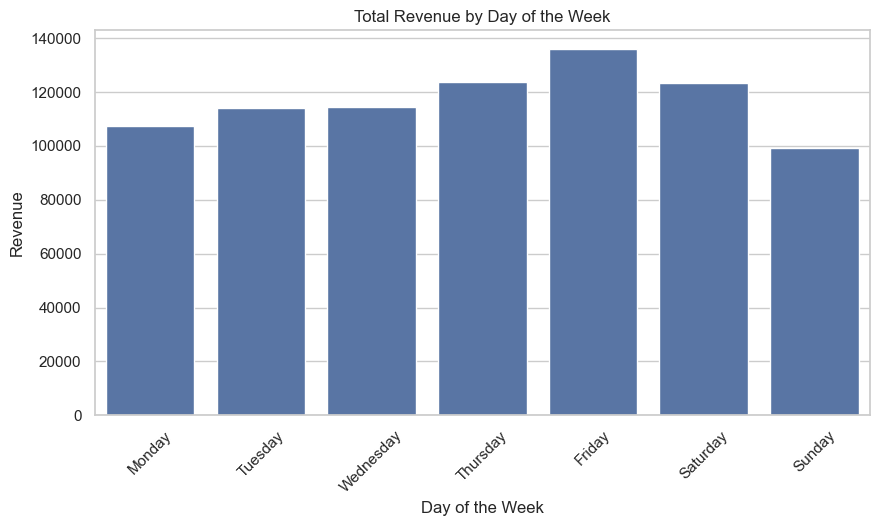

In [79]:
plt.figure(figsize=(10, 5))
sns.barplot(data=sales_by_day, x="day_name", y="total_revenue")
plt.title("Total Revenue by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [85]:
best_day = sales_by_day.sort_values("total_revenue", ascending=False).iloc[0]
print(f"Best sales day: {best_day['day_name']}")
print(f"Revenue: ${best_day['total_revenue']:,.2f}")

Best sales day: Friday
Revenue: $136,073.90


# Top 5 Bestselling Pizzas by Quantity

Insight: The top best selling pizzas by quantity are:

1. The Classic Deluxe Pizza
2. The Barbecue Chicken Pizza
3. The Hawaiian Pizza
4. The Pepperoni Pizza
5. The Thai Chicken Pizza

The Classic Deluxe Pizza sold the most units, making it the most popular pizza by quantity

In [88]:
top_5_pizzas = df.groupby("name").agg(
    total_quantity=("quantity", "sum"),
    total_revenue=("revenue", "sum")
).sort_values("total_quantity", ascending=False).head(5).reset_index()
top_5_pizzas

,name,total_quantity,total_revenue
0,The Classic Deluxe Pizza,2453,38180.50
1,The Barbecue Chicken Pizza,2432,42768.00
2,The Hawaiian Pizza,2422,32273.25
3,The Pepperoni Pizza,2418,30161.75
4,The Thai Chicken Pizza,2371,43434.25


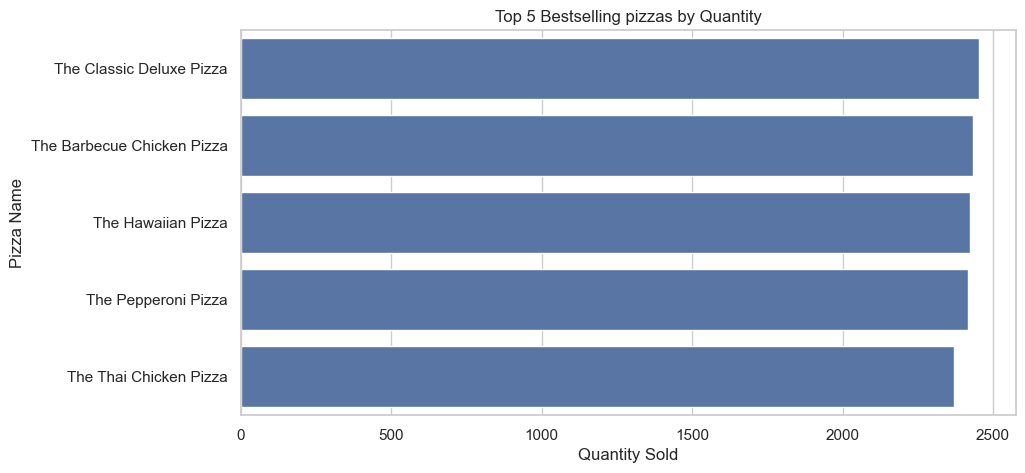

In [90]:
plt.figure(figsize=(10, 5))
sns.barplot(data=top_5_pizzas, x="total_quantity", y="name")
plt.title("Top 5 Bestselling pizzas by Quantity")
plt.xlabel("Quantity Sold")
plt.ylabel("Pizza Name")
plt.show()

# Sales by Month

- Insight: July had highest monthly revenue at $72,557.90, while october had the lowest revenue at $64,027.60. Monthly sales fluctuate, but there is no extreme upward or documented trend across year

In [98]:
monthly_sales = df.groupby(["month", "month_name"]).agg(
    total_revenue=("revenue", "sum"),
    total_quantity=("quantity", "sum"),
    total_orders=("order_id", "nunique")
).reset_index().sort_values("month")

monthly_sales

,month,month_name,total_revenue,total_quantity,total_orders
0,1,January,69793.30,4232,1845
1,2,February,65159.60,3961,1685
2,3,March,70397.10,4261,1840
3,4,April,68736.80,4151,1799
4,5,May,71402.75,4328,1853
5,6,June,68230.20,4107,1773
6,7,July,72557.90,4392,1935
7,8,August,68278.25,4168,1841
8,9,September,64180.05,3890,1661
9,10,October,64027.60,3883,1646


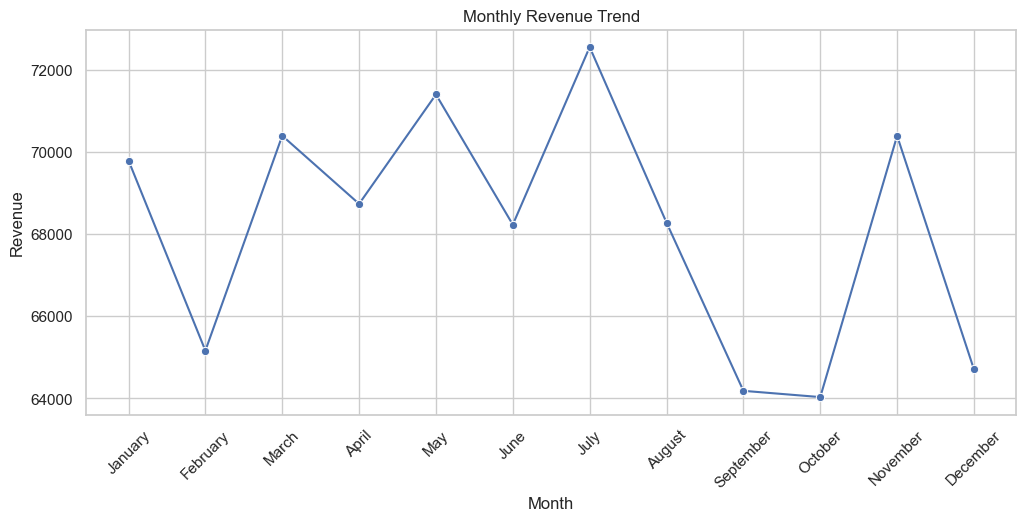

In [102]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_sales, x="month_name", y="total_revenue", marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [104]:
highest_month = monthly_sales.sort_values("total_revenue", ascending=False).iloc[0]
lowest_month = monthly_sales.sort_values("total_revenue", ascending=True).iloc[0]

print(f"Highest revenue month: {highest_month['month_name']} - ${highest_month['total_revenue']:,.2f}")
print(f"Lowest revenue month: {lowest_month['month_name']} - ${lowest_month['total_revenue']:,.2f}")

Highest revenue month: July - $72,557.90
Lowest revenue month: October - $64,027.60


# Pizza Types That Are Not Doing Well

- The Brie Carre Pizza is the weakest-performing pizza by quantity sold, with only 490 units sold. Other low performers include the Mediterranean Pizza, Calabrese Pizza, and Spanish Supreme Pizza. These pizzas may need promotion, recipe cahnges, pricing adjustment, or possible removal from the menu

In [109]:
bottom_pizzas = df.groupby("name").agg(
    total_quantity=("quantity", "sum"),
    total_revenue=("revenue", "sum"),
).sort_values("total_quantity", ascending=True).head(10).reset_index()

bottom_pizzas

,name,total_quantity,total_revenue
0,The Brie Carre Pizza,490,11588.50
1,The Mediterranean Pizza,934,15360.50
2,The Calabrese Pizza,937,15934.25
3,The Spinach Supreme Pizza,950,15277.75
4,The Soppressata Pizza,961,16425.75
5,The Spinach Pesto Pizza,970,15596.00
6,The Chicken Pesto Pizza,973,16701.75
7,The Italian Vegetables Pizza,981,16019.25
8,The Chicken Alfredo Pizza,987,16900.25
9,The Green Garden Pizza,997,13955.75


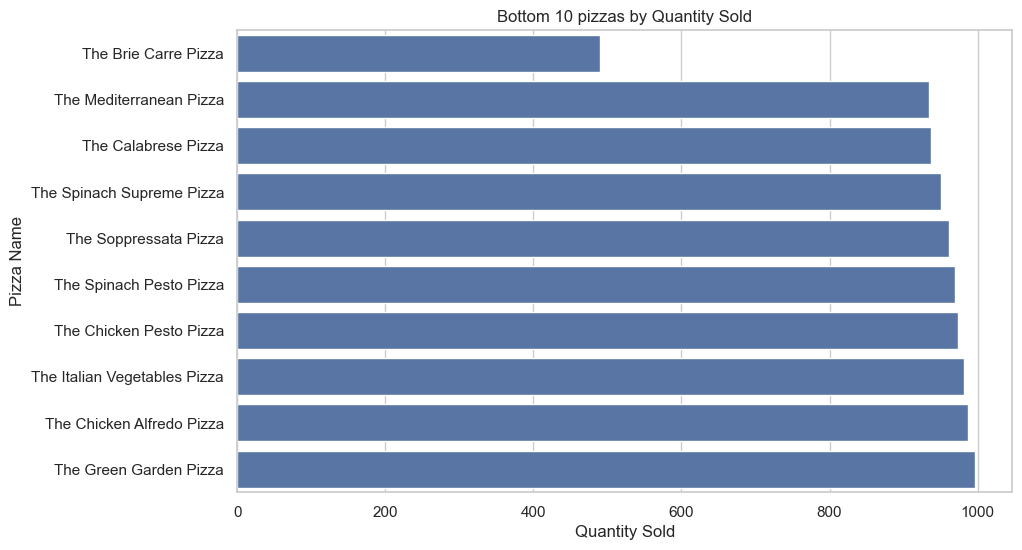

In [111]:
plt.figure(figsize=(10, 6))
sns.barplot(data=bottom_pizzas, x="total_quantity", y="name")
plt.title("Bottom 10 pizzas by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Pizza Name")
plt.show()